# Cuba administrative map

Combine the published **administrative polygons** with **geographic names and point locations** to map Cuba’s provinces and municipalities. Both datasets follow **CoDPA** (*Código de la División Político-Administrativa*), Cuba’s official administrative coding system.

Open this notebook from a local copy of the repository and run the cells in order using a Python environment with **GeoPandas**, **PyArrow**, and **Matplotlib**. The working directory can be the repository root or `examples/`. No online basemap is required.

## Load the data

Read both GeoParquet files and align their coordinate reference systems. For the names table’s structure and hierarchy, see [the geographic names example](administrative_geographic_names.ipynb).


In [13]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "examples":
    ROOT = ROOT.parent

ADMIN_GEOMETRY = ROOT / "data/administrative-geometry/cuba_administrative_geometry.parquet"
ADMIN_NAMES = ROOT / "data/administrative-geographic-names/cuba_administrative_geographic_names.parquet"

units = gpd.read_parquet(ADMIN_GEOMETRY)
names = gpd.read_parquet(ADMIN_NAMES).to_crs(units.crs)
print(f"Administrative units: {len(units):,}")
print(f"Geographic names: {len(names):,}")
print(f"CRS: {units.crs.to_string()}")

Administrative units: 183
Geographic names: 183
CRS: EPSG:4326


## Link names and select levels

Join geometry `gazetteer_id` to geographic names `id`. Label text and positions come from the matched name records.

Province-level areas provide the fills and labels; municipality-level areas provide the internal boundaries. **Isla de la Juventud** is included at both levels through its single `special_municipality` record.


In [14]:
labels = names[["id", "name", "geometry"]].merge(
    units[["gazetteer_id", "level"]],
    left_on="id", right_on="gazetteer_id",
)

province_levels = ["province", "special_municipality"]
municipality_levels = ["municipality", "special_municipality"]
provinces = units.loc[units["level"].isin(province_levels)]
municipalities = units.loc[units["level"].isin(municipality_levels)]
province_labels = labels.loc[labels["level"].isin(province_levels)]

## Draw the map

Colours distinguish provinces, thin lines show municipal boundaries, and labels use the supplied name locations.

The outer outline comes from the combined province polygons, including the islands and keys present in the product. It is not a separate coastline dataset.

Adjust the plotting options below to change the appearance. Uncomment `fig.savefig(...)` to save the map as `examples/administrative_map.png`.


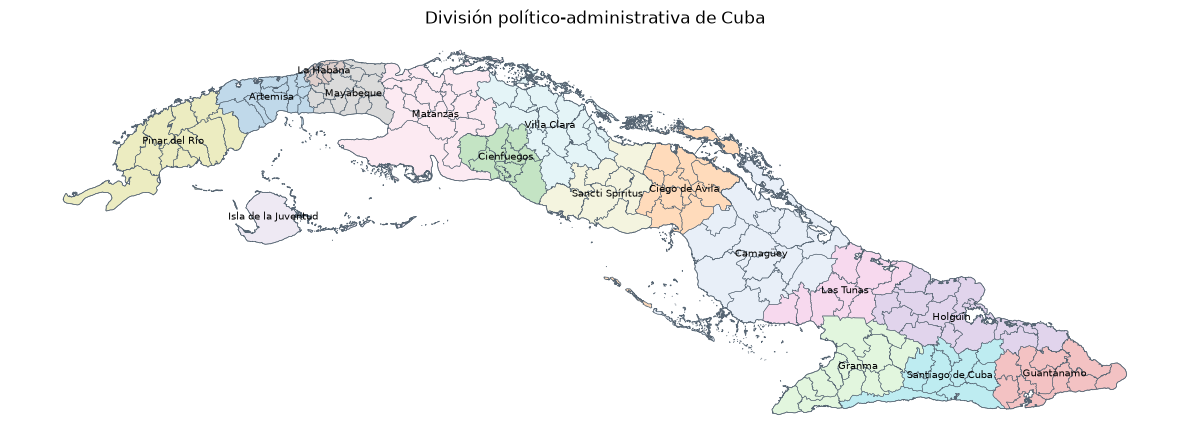

In [15]:
land_outline = gpd.GeoSeries([provinces.geometry.union_all()], crs=units.crs)

fig, ax = plt.subplots(figsize=(12, 9))
provinces.plot(
    ax=ax, column="name", categorical=True, cmap="tab20", alpha=0.28,
    edgecolor="none", legend=False, zorder=1,
)
municipalities.boundary.plot(ax=ax, color="#566573", linewidth=0.35, zorder=2)
land_outline.boundary.plot(ax=ax, color="#566573", linewidth=0.5, zorder=4)

for row in province_labels.itertuples(index=False):
    ax.text(
        row.geometry.x, row.geometry.y, row.name,
        ha="center", va="center", fontsize=7, zorder=5,
    )

ax.set_title("División político-administrativa de Cuba")
ax.set_axis_off()
fig.tight_layout()
plt.show()

# to save the map, uncomment the following line
# fig.savefig(ROOT / "examples/administrative_map.png", dpi=220, bbox_inches="tight")